# HR Analytics: Job Change of Data Scientists

**Binary classification task** - will the candidate look for a new job?

- `target = 1` -> the candidate is **looking** for a job change
- `target = 0` -> the candidate is **not looking** for a job change

## Part 1 - Setup and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Put here the full path to your dataset folder
PATH = 'D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/'

train = pd.read_csv(PATH + 'aug_train.csv')   # data with the answer (target)
test  = pd.read_csv(PATH + 'aug_test.csv')    # data we want to predict

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

Train shape: (19158, 14)
Test  shape: (2129, 13)


In [3]:
train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
print('Missing values per column:')
print(train.isna().sum())
print()
print('Target distribution (0 = not looking, 1 = looking for a job):')
print(train['target'].value_counts(normalize=True))

Missing values per column:
enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

Target distribution (0 = not looking, 1 = looking for a job):
target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64


In [5]:
overview = pd.DataFrame({
    "dtype": train.dtypes,
    "non_null_count": train.notna().sum(),
    "missing_count": train.isna().sum(),
    "missing_%": (train.isna().mean() * 100).round(2),
    "unique_values": train.nunique(),
    "unique_%": (train.nunique() / len(train) * 100).round(2),
})
overview = overview.sort_values("missing_%", ascending=False)
overview

,dtype,non_null_count,missing_count,missing_%,unique_values,unique_%
company_type,object,13018,6140,32.05,6,0.03
company_size,object,13220,5938,30.99,8,0.04
gender,object,14650,4508,23.53,3,0.02
major_discipline,object,16345,2813,14.68,6,0.03
education_level,object,18698,460,2.40,5,0.03
last_new_job,object,18735,423,2.21,6,0.03
enrolled_university,object,18772,386,2.01,3,0.02
experience,object,19093,65,0.34,22,0.11
enrollee_id,int64,19158,0,0.00,19158,100.00
city,object,19158,0,0.00,123,0.64


In [6]:
train['training_hours'].unique()

array([ 36,  47,  83,  52,   8,  24,  18,  46, 123,  32, 108,  23,  26,
       106,   7, 132,  68,  50,  48,  65,  13,  22, 148,  72,  40, 141,
        82, 145, 206, 152,  42,  14, 112,  87,  20,  21,  92, 102,  43,
        45,  19,  90,  25,  15,  98, 142,  28, 228,  29,  12,  17,  35,
         4, 136,  27,  74,  86,  75, 332, 140, 182, 172,  33,  34, 150,
       160,   3,   2, 210, 101,  59, 260, 131, 109,  70,  51,  60, 164,
       290, 133,  76, 156, 120, 100,  39,  55,  49,   6, 125, 326, 198,
        11,  41, 114, 246,  81,  31,  84, 105,  38, 178, 104, 202,  88,
       218,  62,  10,  80,  77,  37, 162, 190,  30,  16,   5,  54,  44,
       110, 262, 107, 134, 103,  96,  57, 240,  94, 113,  56,  64, 320,
         9, 129,  58, 126, 166,  95,  97, 204, 116, 161, 146, 302,  53,
       143, 124, 214, 288, 306, 322,  67,  61, 130, 220,  78, 314, 226,
       280,  91, 234, 163, 151,  85, 256, 168, 144,  66, 128,  73, 122,
       154,  63, 292, 188,  71, 135, 138, 184,  89, 157, 118, 11

## Part 3 - Data Preprocessing

From what we saw in Part 2:
1. `company_size` and `company_type` are connected -> fill with `'Unknown'` and **keep a flag** for `no_company_info`
2. `experience` has only 65 missing -> fill with the most common value
3. `relevent_experience` has no missing at all -> only encoded

In [7]:
def clean_data(df):
    '''Fix missing values and keep the MEANING of the missing data.'''
    df = df.copy()

    # 1) Columns that do not help the model
    df = df.drop(columns=['enrollee_id', 'city'])

    # 2) Keep 'missing company info' as its own feature (we saw it has meaning)
    df['no_company_info'] = (df['company_size'].isna() & df['company_type'].isna()).astype(int)

    # 3) Fill missing values - 'Unknown' stays a real category for the model
    df['gender'].fillna('Unknown', inplace=True)
    df['enrolled_university'].fillna('unknown', inplace=True)
    df['education_level'].fillna('Unknown', inplace=True)
    df['major_discipline'].fillna('Unknown', inplace=True)
    df['company_size'].fillna('Unknown', inplace=True)
    df['company_type'].fillna('Unknown', inplace=True)
    df['experience'].fillna(df['experience'].mode()[0], inplace=True)
    df['last_new_job'].fillna(df['last_new_job'].mode()[0], inplace=True)

    # 4) Text numbers -> real numbers
    df['experience'] = df['experience'].replace({'<1': 0, '>20': 21}).astype(int)
    df['last_new_job'] = df['last_new_job'].replace({'never': 0, '>4': 5}).astype(int)

    return df

In [8]:
def encode_data(df):
    '''Turn all text columns into numbers the model can understand.'''
    df = df.copy()

    # --- Ordinal encoding: the order of the categories matters ---
    education_order = {'Primary School': 1, 'High School': 2, 'Graduate': 3,
                       'Masters': 4, 'Phd': 5, 'Unknown': 0}
    size_order = {'<10': 1, '10/49': 2, '50-99': 3, '100-500': 4, '500-999': 5,
                  '1000-4999': 6, '5000-9999': 7, '10000+': 8, 'Unknown': 0}

    df['education_level'] = df['education_level'].map(education_order)
    df['company_size'] = df['company_size'].map(size_order)

    # --- One-hot encoding: no order, create one column per category ---
    nominal_cols = ['gender', 'relevent_experience', 'enrolled_university',
                    'major_discipline', 'company_type']
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

    return df

In [9]:
train = clean_data(train)
train = encode_data(train)
train['target'] = train['target'].astype(int)   # 0.0 / 1.0 -> 0 / 1

print('Cleaning done! Remaining missing values:', train.isna().sum().sum())
print('Final number of columns:', train.shape[1])
train.head()

Cleaning done! Remaining missing values: 0
Final number of columns: 27


,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,no_company_info,gender_Male,gender_Other,...,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.920,3,21,0,1,36,1,1,True,False,...,False,False,True,False,False,False,False,False,False,True
1,0.776,3,15,3,5,47,0,0,True,False,...,False,False,True,False,False,False,False,False,True,False
2,0.624,3,5,0,0,83,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
3,0.789,3,0,0,0,52,1,0,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0.767,4,21,3,4,8,0,0,True,False,...,False,False,True,False,True,False,False,False,False,False


## Part 4 - Modeling (5 models, many threshold tries)

We train **5 different models**. For every model we try **19 decision thresholds**
and keep the best F1. This way the choice is fair for all models.

In [10]:
# Features (X) and the answer (y)
X = train.drop(columns=['target'])
y = train['target']

# 80% for training, 20% for validation (stratify keeps the same 0/1 balance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,
                                                  random_state=42, stratify=y)
print('Train size:', X_train.shape, '| Validation size:', X_val.shape)

Train size: (15326, 26) | Validation size: (3832, 26)


Total tries: 95
Best result of each model over 19 thresholds:
              model  threshold     f1  accuracy
            XGBoost       0.50 0.6364    0.7868
                SVM       0.35 0.6201    0.7672
      Random Forest       0.30 0.6138    0.7714
Logistic Regression       0.55 0.6006    0.7539
                KNN       0.05 0.5029    0.6203


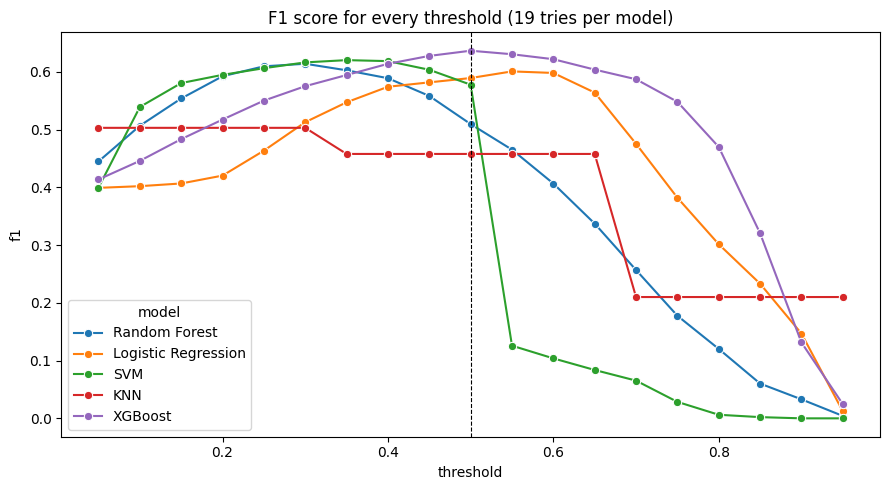

In [11]:
# Scale the data - SVM, KNN and Logistic Regression need it to work well
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 5 different models (XGBoost weight = balances the two classes)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM':                 SVC(class_weight='balanced', random_state=42, probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=3),
    'XGBoost':             XGBClassifier(random_state=42, scale_pos_weight=scale_pos),
}

# Many tries: every model tested with 19 different thresholds (0.05 to 0.95)
thresholds = [round(t, 2) for t in np.arange(0.05, 1.00, 0.05)]

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]      # probability of 'looking for a job'
    for t in thresholds:
        preds = (proba >= t).astype(int)
        results.append({
            'model': name,
            'threshold': t,
            'f1': round(f1_score(y_val, preds), 4),
            'accuracy': round(accuracy_score(y_val, preds), 4),
        })

results = pd.DataFrame(results)
print('Total tries:', len(results))

# Best threshold of each model (highest F1)
best_per_model = results.loc[results.groupby('model')['f1'].idxmax()]\
                      .sort_values('f1', ascending=False)
print('Best result of each model over', len(thresholds), 'thresholds:')
print(best_per_model.to_string(index=False))

# Plot F1 for every threshold - see how the models behave
plt.figure(figsize=(9, 5))
sns.lineplot(data=results, x='threshold', y='f1', hue='model', marker='o')
plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
plt.title('F1 score for every threshold (19 tries per model)')
plt.tight_layout()
plt.show()

Final choice: XGBoost | threshold = 0.5 | F1 = 0.6364
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      2877
           1       0.55      0.75      0.64       955

    accuracy                           0.79      3832
   macro avg       0.73      0.77      0.74      3832
weighted avg       0.82      0.79      0.80      3832



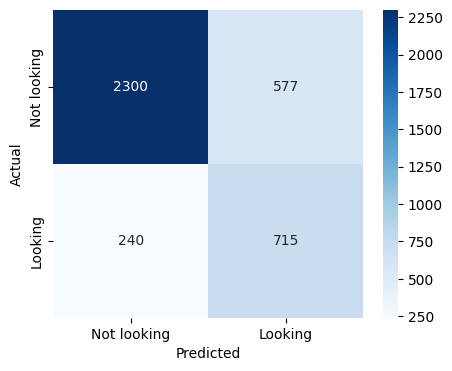

In [12]:
# Final choice: the model + threshold with the best F1
best_row = best_per_model.iloc[0]
final_model = models[best_row['model']]
final_threshold = best_row['threshold']
print(f'Final choice: {best_row["model"]} | threshold = {final_threshold} | F1 = {best_row["f1"]}')

proba = final_model.predict_proba(X_val)[:, 1]
preds = (proba >= final_threshold).astype(int)

print('Classification report:')
print(classification_report(y_val, preds))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not looking', 'Looking'], yticklabels=['Not looking', 'Looking'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part 5 - Predict on Unseen Test Data (optional)

Same preprocessing + same scaling, same model, same threshold.

In [13]:
# Remember the ids before cleaning the test data
test_ids = test['enrollee_id']

test = clean_data(test)
test = encode_data(test)
test = test[X.columns]           # keep the same columns as the training data
test = scaler.transform(test)    # keep the same scaling as the training data

test_pred = (final_model.predict_proba(test)[:, 1] >= final_threshold).astype(int)
print('Predicted distribution:', pd.Series(test_pred).value_counts(normalize=True).to_dict())

submission = pd.DataFrame({'enrollee_id': test_ids, 'target': test_pred})
submission.to_csv(PATH + 'submission.csv', index=False)
submission.head()

Predicted distribution: {0: 0.669798027242837, 1: 0.330201972757163}


,enrollee_id,target
0,32403,0
1,9858,0
2,31806,1
3,27385,0
4,27724,0


In [14]:
# Rank ALL test candidates by their predicted probability (not just the 0/1 label)
test_proba = final_model.predict_proba(test)[:, 1]

ranking = pd.DataFrame({
    'enrollee_id': test_ids.values,
    'probability': test_proba,
})
ranking['predicted_label'] = (ranking['probability'] >= final_threshold).astype(int)
ranking = ranking.sort_values('probability', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1   # rank starting at 1
ranking.index.name = 'rank'

top10 = ranking.head(10)
print('Top 10 candidates most likely to look for a new job:')
top10

Top 10 candidates most likely to look for a new job:


,enrollee_id,probability,predicted_label
rank,,,
1,5980,0.980400,1
2,19550,0.972728,1
3,16336,0.968237,1
4,22510,0.967622,1
5,16462,0.963089,1
6,25129,0.962947,1
7,181,0.962310,1
8,22527,0.959906,1
9,18271,0.958830,1


In [15]:
# Rank the VALIDATION set the same way (it has true labels, so we can check the ranking)
val_proba = final_model.predict_proba(X_val)[:, 1]
val_ranking = pd.DataFrame({
    'true_target': y_val.values,
    'probability': val_proba,
}).sort_values('probability', ascending=False).reset_index(drop=True)

def precision_at_k(df, k):
    top_k = df.head(k)
    return top_k['true_target'].mean()   # fraction of the top k that were really '1'

print('Precision@k on the validation set:')
for k in [10, 20, 50, 100]:
    p = precision_at_k(val_ranking, k)
    print(f'  Precision@{k}: {p:.2f}  ({int(p * k)}/{k} correct)')

overall_rate = y_val.mean()
print(f'\nFor comparison, picking {k} candidates at random would give ~{overall_rate:.2f} precision '
      f'(the overall rate of "looking for a job" in the data).')

Precision@k on the validation set:
  Precision@10: 0.60  (6/10 correct)
  Precision@20: 0.60  (12/20 correct)
  Precision@50: 0.66  (33/50 correct)
  Precision@100: 0.61  (61/100 correct)

For comparison, picking 100 candidates at random would give ~0.25 precision (the overall rate of "looking for a job" in the data).


In [16]:
top10.to_csv(PATH + 'top10_candidates.csv')
print('Saved:', PATH + 'top10_candidates.csv')

Saved: D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/top10_candidates.csv


In [17]:
import joblib

joblib.dump(final_model, PATH + 'final_model.pkl')
joblib.dump(scaler, PATH + 'scaler.pkl')
joblib.dump(final_threshold, PATH + 'final_threshold.pkl')
joblib.dump(X.columns.tolist(), PATH + 'feature_columns.pkl')

print('Saved:')
print(' -', PATH + 'final_model.pkl')
print(' -', PATH + 'scaler.pkl')
print(' -', PATH + 'final_threshold.pkl')
print(' -', PATH + 'feature_columns.pkl')
print()
print(f"Model: {best_row['model']} | Threshold: {final_threshold} | F1: {best_row['f1']}")

Saved:
 - D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/final_model.pkl
 - D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/scaler.pkl
 - D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/final_threshold.pkl
 - D:/iti/HR Analytics_ Job Change of Data Scientists Dataset/feature_columns.pkl

Model: XGBoost | Threshold: 0.5 | F1: 0.6364
